# Baseline Naive Bayes

## import libraries

In [2]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.feature_extraction.text import CountVectorizer,TfidfVectorizer
from sklearn.model_selection import train_test_split
from sklearn.naive_bayes import GaussianNB ,MultinomialNB,BernoulliNB,ComplementNB
from sklearn.metrics import accuracy_score,confusion_matrix,precision_score
from sklearn.metrics import ConfusionMatrixDisplay

In [3]:
df = pd.read_csv('../01_data/spam_clean.csv',encoding="utf-8")
df


,target,transformed_text
0,0,go jurong point crazi avail bugi n great world...
1,0,ok lar joke wif u oni
2,1,free entri 2 wkli comp win fa cup final tkt 21...
3,0,u dun say earli hor u c alreadi say
4,0,nah think goe usf live around though
...,...,...
5164,1,2nd time tri 2 contact u pound prize 2 claim e...
5165,0,b go esplanad fr home
5166,0,piti mood suggest
5167,0,guy bitch act like interest buy someth els nex...


In [4]:
# fill the missing values 
df['transformed_text'] = df['transformed_text'].fillna('')

## Vectorization
convert text to vector 

In [5]:
cv = CountVectorizer()
tfidf = TfidfVectorizer(max_features=3000)

X = tfidf.fit_transform(df['transformed_text']).toarray()
X

array([[0., 0., 0., ..., 0., 0., 0.],
       [0., 0., 0., ..., 0., 0., 0.],
       [0., 0., 0., ..., 0., 0., 0.],
       ...,
       [0., 0., 0., ..., 0., 0., 0.],
       [0., 0., 0., ..., 0., 0., 0.],
       [0., 0., 0., ..., 0., 0., 0.]])

In [6]:
y = df['target'].to_numpy()
y

array([0, 0, 1, ..., 0, 0, 0], dtype=int64)

In [7]:
print(X.shape)
print(y.shape)

(5169, 3000)
(5169,)


## train test split 

In [8]:
X_train,X_test,y_train,y_test = train_test_split(X,y,test_size=0.2,random_state=2)

## Model train and evaultion 

In [23]:
# Initialize all 4 Naive Bayes variants
models = {
    "GaussianNB": GaussianNB(),
    "MultinomialNB": MultinomialNB(),
    "BernoulliNB": BernoulliNB(),
    "ComplementNB": ComplementNB(),
}

#  Train, Predict, and Evaluate
results = []

for name, model in models.items():
    model.fit(X_train, y_train)
    y_pred = model.predict(X_test)

    acc = accuracy_score(y_test, y_pred)
    prec = precision_score(y_test, y_pred)

    results.append({"Model": name, "Accuracy": acc, "Precision": prec})


results_df = pd.DataFrame(results).sort_values(by="Precision", ascending=False)
print(results_df.to_string(index=False))

        Model  Accuracy  Precision
MultinomialNB  0.972921   1.000000
  BernoulliNB  0.982592   0.991803
 ComplementNB  0.911992   0.613527
   GaussianNB  0.870406   0.508929


## Confusion Matrix Display

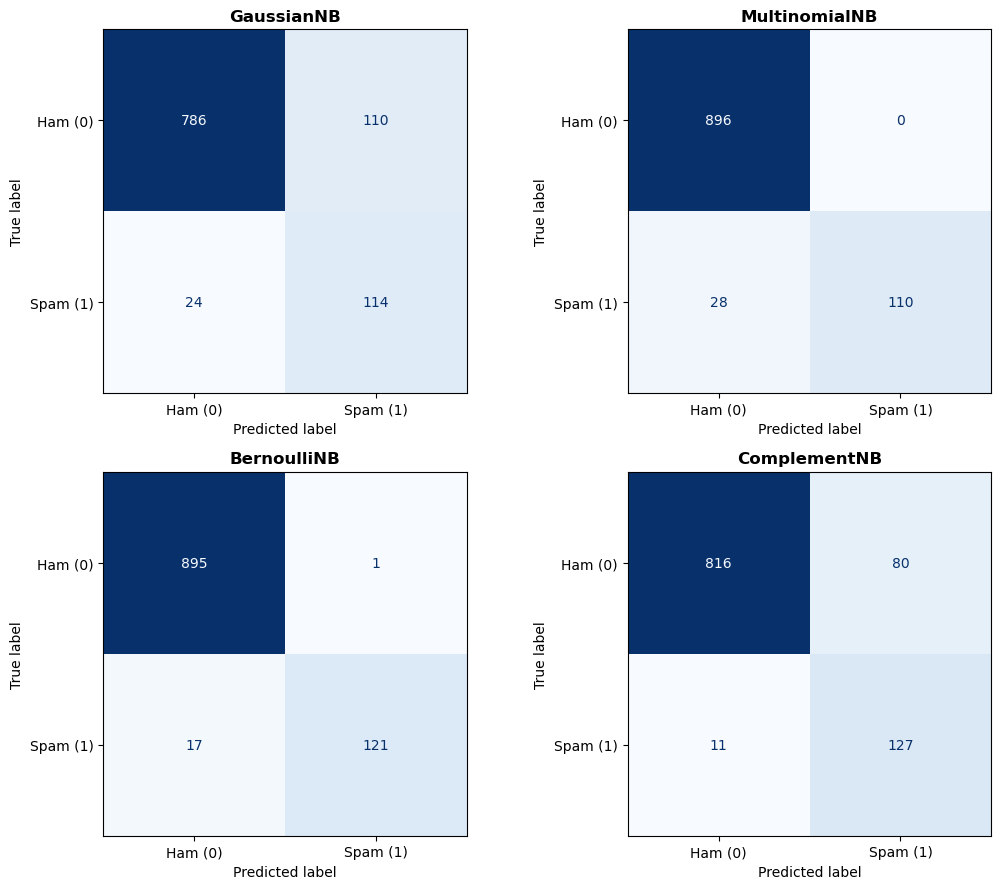

        Model  Accuracy  Precision  False Positives  False Negatives
MultinomialNB    0.9729     1.0000                0               28
  BernoulliNB    0.9826     0.9918                1               17
 ComplementNB    0.9120     0.6135               80               11
   GaussianNB    0.8704     0.5089              110               24


In [24]:
# 1. Initialize all 4 Naive Bayes variants
models = {
    "GaussianNB": GaussianNB(),
    "MultinomialNB": MultinomialNB(),
    "BernoulliNB": BernoulliNB(),
    "ComplementNB": ComplementNB(),
}

# 2. Setup figure for a 2x2 grid
fig, axes = plt.subplots(2, 2, figsize=(11, 9))
results = []

# 3. Train, Evaluate, and Plot using ConfusionMatrixDisplay
for ax, (name, model) in zip(axes.ravel(), models.items()):
    model.fit(X_train, y_train)
    y_pred = model.predict(X_test)

    cm = confusion_matrix(y_test, y_pred)
    acc = accuracy_score(y_test, y_pred)
    prec = precision_score(y_test, y_pred, zero_division=0)

    results.append(
        {
            "Model": name,
            "Accuracy": round(acc, 4),
            "Precision": round(prec, 4),
            "False Positives": cm[0, 1],
            "False Negatives": cm[1, 0],
        }
    )

    # Scikit-Learn ConfusionMatrixDisplay
    disp = ConfusionMatrixDisplay(
        confusion_matrix=cm, display_labels=["Ham (0)", "Spam (1)"]
    )
    disp.plot(cmap=plt.cm.Blues, ax=ax, colorbar=False)
    ax.set_title(f"{name}", fontsize=12, fontweight="bold")

plt.tight_layout()
plt.show()

# 4. Display sorted metrics summary
results_df = pd.DataFrame(results).sort_values(
    by=["Precision", "Accuracy"], ascending=False
)
print(results_df.to_string(index=False))

# All Classfications Models

## import classifers

In [9]:
from sklearn.linear_model import LogisticRegression
from sklearn.neighbors import KNeighborsClassifier
from sklearn.naive_bayes import MultinomialNB
from sklearn.svm import SVC
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.ensemble import GradientBoostingClassifier
from xgboost import XGBClassifier

## Basic Hyperparameter tunining

In [10]:
classifiers = {
    "LogisticRegression" : LogisticRegression(solver='liblinear',penalty="l1"),
    "K-NeighborsClassifier": KNeighborsClassifier(),
    "MultinomialNB": MultinomialNB(),
    "SVC": SVC(kernel='sigmoid',gamma=1.0) ,
    "DecisionTreeClassifier" : DecisionTreeClassifier(max_depth=5,random_state=2),
    "Random Forest": RandomForestClassifier(n_estimators=50, random_state=2),
    "Gradient Boosting": GradientBoostingClassifier(n_estimators=50, random_state=2),
    "XGBoost": XGBClassifier(n_estimators=50, random_state=2, eval_metric="logloss")
}

## train classifers

In [11]:
def train_classifer(classifier_model,X_train,y_train, X_test,y_test):
    classifier_model.fit(X_train,y_train)
    y_pred = classifier_model.predict(X_test)
    
    accuracy = accuracy_score(y_test,y_pred)
    precision = precision_score(y_test,y_pred)
    
    return accuracy,precision

## Evaultion

In [19]:

accuracy_scores = []
precision_scores = []

for name, classifier in classifiers.items():
    current_accuracy, current_precision = train_classifer(
        classifier, X_train, y_train, X_test, y_test
    )

    print(f"For {name}")
    print(f"  Accuracy  : {current_accuracy:.4f}")
    print(f"  Precision : {current_precision:.4f}\n")

    accuracy_scores.append(current_accuracy)
    precision_scores.append(current_precision)


For LogisticRegression
  Accuracy  : 0.9565
  Precision : 0.9697

For K-NeighborsClassifier
  Accuracy  : 0.9052
  Precision : 1.0000

For MultinomialNB
  Accuracy  : 0.9729
  Precision : 1.0000

For SVC
  Accuracy  : 0.9758
  Precision : 0.9748

For DecisionTreeClassifier
  Accuracy  : 0.9294
  Precision : 0.8283

For Random Forest
  Accuracy  : 0.9691
  Precision : 0.9732

For Gradient Boosting
  Accuracy  : 0.9468
  Precision : 0.9278

For XGBoost
  Accuracy  : 0.9681
  Precision : 0.9487



In [16]:
# Create and Sort Leaderboard
performance_df = pd.DataFrame(
    {
        "Algorithm": list(classifiers.keys()),
        "Accuracy": accuracy_scores,
        "Precision": precision_scores,
    }
).sort_values(by=["Precision", "Accuracy"], ascending=False)
performance_df

,Algorithm,Accuracy,Precision
2,MultinomialNB,0.972921,1.000000
1,K-NeighborsClassifier,0.905222,1.000000
3,SVC,0.975822,0.974790
5,Random Forest,0.969052,0.973214
0,LogisticRegression,0.956480,0.969697
7,XGBoost,0.968085,0.948718
6,Gradient Boosting,0.946809,0.927835
4,DecisionTreeClassifier,0.929400,0.828283


## final comparions table

In [20]:
print(performance_df.to_string(index=False))

             Algorithm  Accuracy  Precision
         MultinomialNB  0.972921   1.000000
 K-NeighborsClassifier  0.905222   1.000000
                   SVC  0.975822   0.974790
         Random Forest  0.969052   0.973214
    LogisticRegression  0.956480   0.969697
               XGBoost  0.968085   0.948718
     Gradient Boosting  0.946809   0.927835
DecisionTreeClassifier  0.929400   0.828283


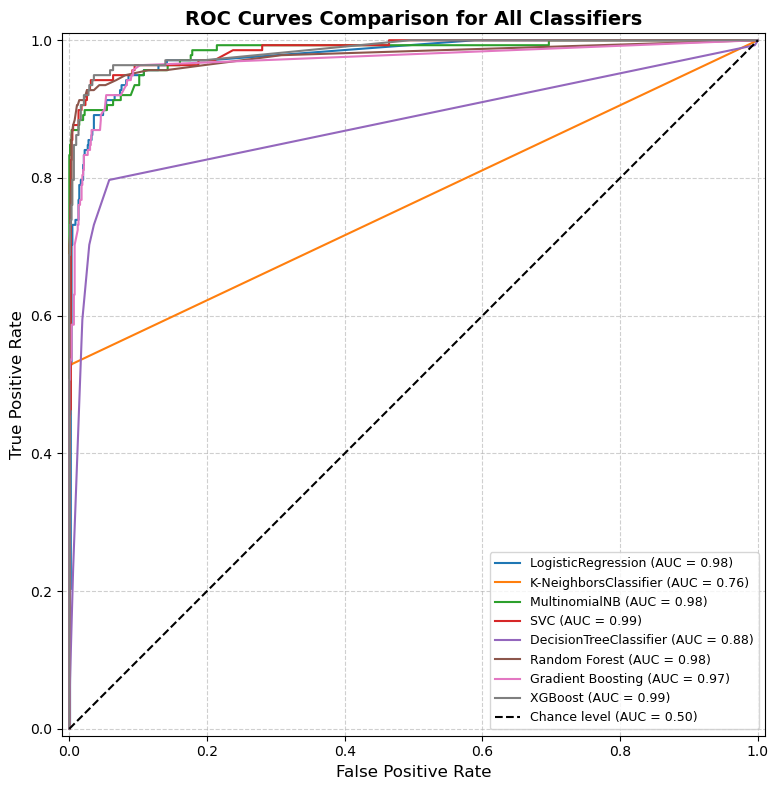

In [15]:
import matplotlib.pyplot as plt
from sklearn.metrics import RocCurveDisplay

# 1. Create a single Matplotlib figure and axis
fig, ax = plt.subplots(figsize=(10, 8))

# 2. Iterate through all classifiers and plot onto the same axis
for name, clf in classifiers.items():
    RocCurveDisplay.from_estimator(
        clf,
        X_test,
        y_test,
        ax=ax,  # Plots all curves onto the shared axis
        name=name,  # Custom label in the legend with auto-computed AUC
    )

# 3. Add a diagonal chance baseline (random guess line)
ax.plot([0, 1], [0, 1], "k--", label="Chance level (AUC = 0.50)")

# 4. Styling & Labels
ax.set_title(
    "ROC Curves Comparison for All Classifiers", fontsize=14, fontweight="bold"
)
ax.set_xlabel("False Positive Rate", fontsize=12)
ax.set_ylabel("True Positive Rate", fontsize=12)
ax.grid(True, linestyle="--", alpha=0.6)
ax.legend(loc="lower right", fontsize=9)

plt.tight_layout()
plt.show()

In [ ]:
# import the dataset 
df = pd.read_csv('../01_data/spam_clean.csv',encoding="utf-8")

# fill the missing values 
df['transformed_text'] = df['transformed_text'].fillna('')

# convert text to vector 
cv = CountVectorizer()
tfidf = TfidfVectorizer(max_features=3000)

X = tfidf.fit_transform(df['transformed_text']).toarray()
y = df['target'].to_numpy()

X_train,X_test,y_train,y_test = train_test_split(X,y,test_size=0.2,random_state=2)

final_model = MultinomialNB()
final_model.fit(X_train,y_train)

MultinomialNB()

In [27]:
import os
import pickle

# Ensure artifacts directory exists
os.makedirs("../03_models", exist_ok=True)

In [28]:
# Serialize and save the vectorizer & model

with open("../03_models/vectorizer.pkl", "wb") as f:
    pickle.dump(tfidf, f)

with open("../03_models/model.pkl", "wb") as f:
    pickle.dump(final_model, f)

print(
    "Successfully exported 'models/vectorizer.pkl' and 'models/model.pkl'"
)

Successfully exported 'models/vectorizer.pkl' and 'models/model.pkl'
